# Support Vector Machines (SVMs)

Support vector machines perform the same task as logistic regression except that they find the **best** splitting hyperplane between data points. "Best" is defined by the margin — the distance from the hyperplane to the closest point in each class. The goal is to find the hyperplane that **maximizes this margin**.

Training SVMs is also different from other ML models: instead of gradient descent, we solve a **convex optimization problem**, which always has a unique global minimum.

## Primal Form

Formally, we want to find weights $\mathbf{w}$ and bias $b$ such that the margin $\frac{2}{\|\mathbf{w}\|}$ is maximized — which is equivalent to minimizing $\|\mathbf{w}\|^2$:

$$\min_{\mathbf{w},\, b} \frac{1}{2} \|\mathbf{w}\|^2 \quad \text{s.t.} \quad y_i(\mathbf{w}^\top \mathbf{x}_i + b) \geq 1 \quad \forall\, i$$

This is the **primal form**. The constraint ensures every point is correctly classified and lies outside (or exactly on) the margin boundary.

## Dual Form

To solve this efficiently — and to later enable kernel tricks — we convert to the **dual form** using Lagrange multipliers $\alpha_i \geq 0$, one per training point:

$$\max_{\boldsymbol{\alpha}} \sum_{i} \alpha_i - \frac{1}{2} \sum_{i} \sum_{j} \alpha_i \alpha_j y_i y_j\, \mathbf{x}_i^\top \mathbf{x}_j \quad \text{s.t.} \quad \sum_{i} \alpha_i y_i = 0,\quad \alpha_i \geq 0$$

A key insight here: the dual only depends on **dot products** $\mathbf{x}_i^\top \mathbf{x}_j$, not the raw feature vectors. This is the foundation for kernel SVMs.

Once $\boldsymbol{\alpha}$ is known, we recover the primal solution:

$$\mathbf{w} = \sum_{i} \alpha_i y_i \mathbf{x}_i$$

The points where $\alpha_i > 0$ are called **support vectors** — they are the only training points that actually define the hyperplane. The bias $b$ is recovered from any support vector using the KKT condition $y_i(\mathbf{w}^\top \mathbf{x}_i + b) = 1$.

## Solving with cvxopt

Thankfully, we don't need to implement a solver ourselves — `cvxopt` handles it. It expects a **minimization** problem in standard QP form:

$$\min_{\mathbf{x}} \frac{1}{2} \mathbf{x}^\top P \mathbf{x} + \mathbf{q}^\top \mathbf{x} \quad \text{s.t.} \quad G\mathbf{x} \leq \mathbf{h},\quad A\mathbf{x} = \mathbf{b}$$

Since our dual is a maximization, we flip the sign and map each term to cvxopt's arguments:

| Argument | Shape | What it encodes |
|----------|-------|-----------------|
| `P` | $(n \times n)$ | $P_{ij} = y_i y_j\, \mathbf{x}_i^\top \mathbf{x}_j$ — the quadratic term |
| `q` | $(n \times 1)$ | $-\mathbf{1}$ — because we flipped $\max \sum \alpha_i$ to $\min -\sum \alpha_i$ |
| `A` | $(1 \times n)$ | $\mathbf{y}^\top$ — encodes the equality constraint $\sum \alpha_i y_i = 0$ |
| `b` | scalar | $0$ — right-hand side of the equality constraint |
| `G` | $(n \times n)$ or $(2n \times n)$ | Inequality constraints on $\boldsymbol{\alpha}$ |
| `h` | $(n,)$ or $(2n,)$ | Right-hand side of the inequality constraints |

**Hard margin** ($C = \infty$): only $\alpha_i \geq 0$ is enforced, so $G = -I$ and $\mathbf{h} = \mathbf{0}$.

**Soft margin** (finite $C$): we additionally enforce $\alpha_i \leq C$, allowing some misclassification. Both constraints are stacked:

$$G = \begin{bmatrix} -I \\ I \end{bmatrix}, \quad \mathbf{h} = \begin{bmatrix} \mathbf{0} \\ C \cdot \mathbf{1} \end{bmatrix}$$

$C$ controls the trade-off: a smaller $C$ allows more violations (wider margin, softer boundary); a larger $C$ penalizes violations heavily (harder boundary, closer to hard margin).

A couple of notes:

- The table column `G`/`h` shapes change between hard and soft margin because `np.vstack` doubles the rows — that's worth keeping in mind when you implement it

- The `b` in cvxopt (`np.zeros(1)`) is a different `b` from the SVM bias — unfortunate naming clash in the standard QP formulation

## Imports

In [79]:
import numpy as np
import cvxopt
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cvxopt.solvers.options['show_progress'] = False

## `SVM` Class

In [ ]:
class SVM:
    def __init__(self):
        self.w = 0
        self.bias = 0
        self.sv_X = []

    def fit(self, X, y, C=None):
        n_samples, _ = X.shape

        K = (y[:, None] * X) @ (y[:, None] * X).T

        P = cvxopt.matrix(K.astype(float))
        q = cvxopt.matrix(-np.ones((n_samples, 1)))
        A = cvxopt.matrix(y.reshape(1, -1).astype(float))
        b = cvxopt.matrix(np.zeros(1))

        if C is None:
            G = cvxopt.matrix(-np.eye(n_samples))
            h = cvxopt.matrix(np.zeros(n_samples))
        else:
            G = cvxopt.matrix(np.vstack((-np.eye(n_samples), np.eye(n_samples))))
            h = cvxopt.matrix(np.hstack((np.zeros(n_samples), np.ones(n_samples) * C)))

        soln = cvxopt.solvers.qp(P, q, G, h, A, b)
        alphas = np.array(soln['x']).flatten()

        # Only support vectors have non-zero Lagrangian Parameters
        sv_idx = alphas > 1e-5
        sv_X = X[sv_idx]
        sv_y = y[sv_idx]

        w = ((alphas * y)[:, None] * X).sum(axis=0)
        bias = sv_y[0] - np.dot(sv_X[0], w)  # from KKT: y_i(w·x_i + b) = 1

        self.w = w
        self.bias = bias
        self.sv_X = sv_X

    def plot(self, X, y, title, subplot_info):
        background = ListedColormap(['cyan', 'lightgreen'])
        foreground = ListedColormap(['blue', 'green'])

        plt.subplot(*subplot_info)
        x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
        y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                             np.linspace(y_min, y_max, 300))
        Z = self.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
        plt.pcolormesh(xx, yy, Z, cmap=background, alpha=0.3, shading='auto')

        plt.scatter(X[:, 0], X[:, 1], c=y, cmap=foreground)
        plt.scatter(self.sv_X[:, 0], self.sv_X[:, 1], s=100, facecolors='none', edgecolors='k', label='SVs')

        x_plot = np.linspace(x_min, x_max, 100)
        y_plot       = (-self.w[0] * x_plot - self.bias) / self.w[1]        # decision boundary: w·x + b = 0
        y_margin_pos = (1 - self.w[0] * x_plot - self.bias) / self.w[1]     # positive margin: w·x + b = +1
        y_margin_neg = (-1 - self.w[0] * x_plot - self.bias) / self.w[1]    # negative margin: w·x + b = -1

        plt.plot(x_plot, y_plot, 'k-', linewidth=2, label='Decision Boundary')
        plt.plot(x_plot, y_margin_pos, 'r--', linewidth=2, label='Margins')
        plt.plot(x_plot, y_margin_neg, 'r--', linewidth=2)
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.legend()
        plt.ylim(y_min, y_max)

    def predict(self, X):
        return np.sign(X @ self.w + self.bias)

## Visualization

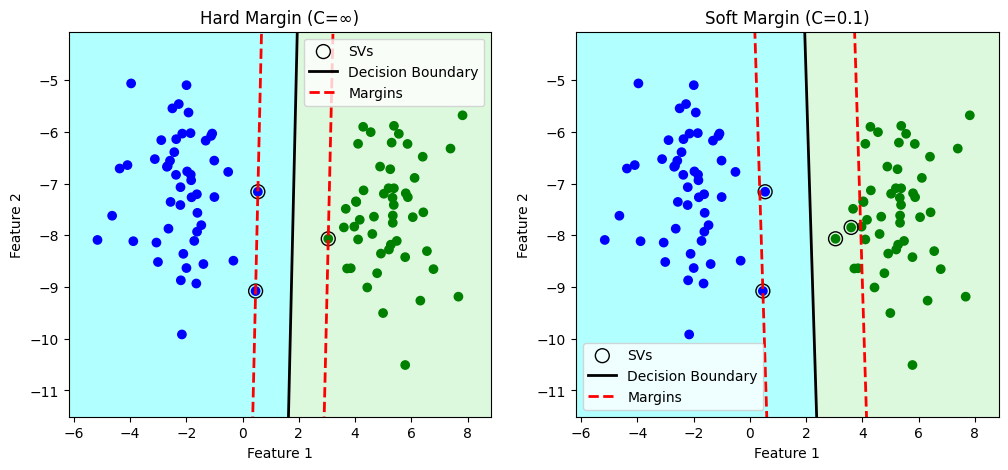

In [89]:
X, y = make_blobs(n_samples=100, n_features=2, centers=2)
y[y == 0] = -1

hard_margin_svm = SVM()
soft_margin_svm = SVM()

hard_margin_svm.fit(X, y, C=None)
soft_margin_svm.fit(X, y, C=0.1)

plt.figure(figsize=(12, 5))
hard_margin_svm.plot(X, y, 'Hard Margin (C=∞)', (1, 2, 1))
soft_margin_svm.plot(X, y, 'Soft Margin (C=0.1)', (1, 2, 2))

# plt.tight_layout()
plt.show()